# CIFAR-10 Training

**Corduneanu-Huci Mia & Haltrich Nika**

- Random Forest
- CNN
- ResNet-18
- ResNet-50
- Neural ODE

### Import libraries

In [ ]:
import os
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.autograd import Variable
from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, AveragePooling2D, Flatten, LSTM, Dense, TimeDistributed, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

In [2]:
# device
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

GRAYSCALE = False

MODEL_TYPE = 'resnet'

print(f"Using device: {DEVICE}")
print(f"Model type: {MODEL_TYPE}")

Using device: cuda
Model type: resnet


## Dataset

### CIFAR-10 DATASET

In [ ]:
# load data
(X_train, y_train_raw), (X_test, y_test_raw) = cifar10.load_data()

# normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print(X_train.shape)
print(X_test.shape)

# flat integer labels for shallow models (RF, XGBoost)
y_train_flat = y_train_raw.flatten() # 1d array of integer labels
y_test_flat  = y_test_raw.flatten()

# one-hot encode labels for Keras CNNs
y_train = to_categorical(y_train_raw, 10) # vector
y_test  = to_categorical(y_test_raw, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


## Model Definitions


### Random Forest

In [ ]:
def extract_features(images):
    features = []
    for img in images:
        color_means = img.mean(axis=(0, 1)) # mean R, G, B (3 dims)
        color_stds  = img.std(axis=(0, 1)) # std  R, G, B (3 dims)
        gray        = img.mean(axis=2) # grayscale(32×32)
        flat_gray   = gray.flatten() # pixel values(1024 dims
        features.append(np.concatenate([color_means, color_stds, flat_gray]))
    return np.array(features) # total: 1030 dims

X_train_feats = extract_features(X_train[:10000])
X_test_feats  = extract_features(X_test[:2000])

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None, # grow full trees, but tune down if overfitting
    min_samples_leaf=1,
    max_features="sqrt", # standard for classification
    n_jobs=-1, # use all CPU cores
    random_state=42,
)
rf_start_train = time.time()
clf.fit(X_train_feats, y_train_flat[:10000])
rf_train_time = time.time() - rf_start_train
print(f"RF Train time: {rf_train_time:.2f}s")


# evaluate
rf_start_test = time.time()
y_pred = clf.predict(X_test_feats)
rf_test_time = time.time() - rf_start_test
print(f"RF Test time: {rf_test_time:.2f}s")
N_TEST = 2000  # define N_TEST here so comparison table can use it
print(classification_report(y_test_flat[:N_TEST], y_pred, target_names=[
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]))


rf_acc = accuracy_score(y_test_flat[:N_TEST], y_pred)
print(f"Accuracy: {rf_acc:.4f}")


RF Train time: 16.05s
RF Test time: 0.14s
              precision    recall  f1-score   support

    airplane       0.34      0.38      0.36       196
  automobile       0.43      0.42      0.42       198
        bird       0.23      0.17      0.20       195
         cat       0.23      0.11      0.15       199
        deer       0.25      0.29      0.27       198
         dog       0.30      0.27      0.28       185
        frog       0.36      0.46      0.40       216
       horse       0.32      0.29      0.31       193
        ship       0.44      0.52      0.48       217
       truck       0.36      0.42      0.39       203

    accuracy                           0.34      2000
   macro avg       0.33      0.33      0.33      2000
weighted avg       0.33      0.34      0.33      2000

Accuracy: 0.3370


### CNN

In [5]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

#### CNN training

##### CNN1

In [6]:
cnn_model = Sequential() # def a sequential CNN model
cnn_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3))) # first layer, 32 convolutional neurons of size 3x3, relu activation
cnn_model.add(MaxPooling2D((2, 2))) # reduces spatial dimensions
cnn_model.add(Dropout(0.25)) # reduce overfitting (randomly sets 25% of inputs to 0 during training)
cnn_model.add(Flatten()) # flatten the 2D feature maps into a 1D vector for fully connected vectors
cnn_model.add(Dense(128, activation='relu')) # fully connected layer
cnn_model.add(Dropout(0.5)) # 50% of neurons dropped
cnn_model.add(Dense(10, activation='softmax')) # output layer -> 10 neurons (softmax activation for probabilities)
# dense fully connected layer(with 256)
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) # compiles the model
cnn1_start_train = time.time()
cnn_history = cnn_model.fit(X_train, y_train, epochs=12, batch_size=32, validation_data=(X_test, y_test))
cnn1_train_time = time.time() - cnn1_start_train
# test timing
cnn1_start_test = time.time()
_ = cnn_model.predict(X_test, verbose=0)
cnn1_test_time = time.time() - cnn1_start_test
_, cnn1_acc = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy: {cnn1_acc:.4f} | Train: {cnn1_train_time:.1f}s | Test: {cnn1_test_time:.2f}s") # trains the model on the training set


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.3651 - loss: 1.7195 - val_accuracy: 0.5137 - val_loss: 1.4004
Epoch 2/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4600 - loss: 1.4895 - val_accuracy: 0.5472 - val_loss: 1.2733
Epoch 3/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4925 - loss: 1.4036 - val_accuracy: 0.5470 - val_loss: 1.2983
Epoch 4/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5131 - loss: 1.3439 - val_accuracy: 0.6022 - val_loss: 1.1468
Epoch 5/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5315 - loss: 1.2955 - val_accuracy: 0.6075 - val_loss: 1.1292
Epoch 6/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.5454 - loss: 1.2633 - val_accuracy: 0.6214 - val_loss: 1.1015
Epoch 7/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5568 - loss: 1.2341 - val_accuracy: 0.6230 - val_loss: 1.0808
Epoch 8/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5647 - loss: 1.2116 

- (32, 32, 3) = 32x32 pixels, RGB color (3 layers: Red, Green, Blue)

##### CNN 2

In [7]:
cnn_model_2 = Sequential()
cnn_model_2.add(Input(shape=(32,32,3)))

# more convolutional layers
# first layer
cnn_model_2.add(Conv2D(16, (3, 3), activation='relu'))
cnn_model_2.add(MaxPooling2D((2, 2)))

# second layer
cnn_model_2.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
cnn_model_2.add(MaxPooling2D(pool_size=(2,2)))

cnn_model_2.add(Flatten())
cnn_model_2.add(Dense(128, activation='relu'))
cnn_model_2.add(Dropout(0.5))
cnn_model_2.add(Dense(10, activation='softmax'))

cnn_model_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn2_start_train = time.time()
cnn_history = cnn_model_2.fit(X_train, y_train, epochs=12, batch_size=32, validation_data=(X_test, y_test))
cnn2_train_time = time.time() - cnn2_start_train
# Test timing
cnn2_start_test = time.time()
_ = cnn_model_2.predict(X_test, verbose=0)
cnn2_test_time = time.time() - cnn2_start_test
_, cnn2_acc = cnn_model_2.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy: {cnn2_acc:.4f} | Train: {cnn2_train_time:.1f}s | Test: {cnn2_test_time:.2f}s")


Epoch 1/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.4015 - loss: 1.6415 - val_accuracy: 0.5224 - val_loss: 1.3299
Epoch 2/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5245 - loss: 1.3300 - val_accuracy: 0.5964 - val_loss: 1.1542
Epoch 3/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5718 - loss: 1.2059 - val_accuracy: 0.6291 - val_loss: 1.0576
Epoch 4/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6021 - loss: 1.1380 - val_accuracy: 0.6216 - val_loss: 1.0840
Epoch 5/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6182 - loss: 1.0851 - val_accuracy: 0.6629 - val_loss: 0.9820
Epoch 6/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6337 - loss: 1.0426 - val_accuracy: 0.6631 - val_loss: 0.9701
Epoch 7/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6466 - loss: 1.0033 - val_accuracy: 0.6652 - val_loss: 0.9510
Epoch 8/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6557 - loss: 0.9812 -

##### CNN 3

In [8]:
cnn_model_3 = Sequential()
cnn_model_3.add(Input(shape=(32,32,3)))

# first layer
cnn_model_3.add(Conv2D(32, (3, 3), activation='relu'))
cnn_model_3.add(MaxPooling2D((2, 2)))

# second layer
cnn_model_3.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model_3.add(MaxPooling2D((2, 2)))

# third layer
cnn_model_3.add(Conv2D(128, (3, 3), activation='relu'))
#cnn_model_3.add(MaxPooling2D((2,2)))

cnn_model_3.add(Flatten())
cnn_model_3.add(Dense(128, activation='relu'))
cnn_model_3.add(Dropout(0.5))
cnn_model_3.add(Dense(10, activation='softmax'))

cnn_model_3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn3_start_train = time.time()
cnn_history = cnn_model_3.fit(X_train, y_train, epochs=12, batch_size=32, validation_data=(X_test, y_test))
cnn3_train_time = time.time() - cnn3_start_train
# Test timing
cnn3_start_test = time.time()
_ = cnn_model_3.predict(X_test, verbose=0)
cnn3_test_time = time.time() - cnn3_start_test
_, cnn3_acc = cnn_model_3.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy: {cnn3_acc:.4f} | Train: {cnn3_train_time:.1f}s | Test: {cnn3_test_time:.2f}s")


Epoch 1/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4024 - loss: 1.6276 - val_accuracy: 0.5538 - val_loss: 1.2405
Epoch 2/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5546 - loss: 1.2691 - val_accuracy: 0.6247 - val_loss: 1.0522
Epoch 3/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6130 - loss: 1.1092 - val_accuracy: 0.6386 - val_loss: 1.0320
Epoch 4/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6530 - loss: 1.0009 - val_accuracy: 0.6561 - val_loss: 0.9981
Epoch 5/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6810 - loss: 0.9164 - val_accuracy: 0.6942 - val_loss: 0.8804
Epoch 6/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7020 - loss: 0.8562 - val_accuracy: 0.7045 - val_loss: 0.8502
Epoch 7/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7250 - loss: 0.7932 - val_accuracy: 0.6904 - val_loss: 0.9067
Epoch 8/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7402 - loss: 0.7473 -

##### CNN different pooling

In [9]:
cnn_model_4 = Sequential()
cnn_model_4.add(Input(shape=(32,32,3)))

# first layer
cnn_model_4.add(Conv2D(32, (3, 3), activation='relu'))
cnn_model_4.add(AveragePooling2D((2,2))) # reduces the spatial dimensions

# second layer
cnn_model_4.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model_4.add(AveragePooling2D((2,2)))

# third layer
cnn_model_4.add(Conv2D(128, (3, 3), activation='relu'))
cnn_model_4.add(AveragePooling2D((2,2)))

cnn_model_4.add(Flatten()) # 3D feature maps into 1D vector
cnn_model_4.add(Dense(128, activation='relu'))
cnn_model_4.add(Dropout(0.5))
cnn_model_4.add(Dense(10, activation='softmax'))

cnn_model_4.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn4_start_train = time.time()
cnn_history = cnn_model_4.fit(X_train, y_train, epochs=12, batch_size=32, validation_data=(X_test, y_test))
cnn4_train_time = time.time() - cnn4_start_train
# Test timing
cnn4_start_test = time.time()
_ = cnn_model_4.predict(X_test, verbose=0)
cnn4_test_time = time.time() - cnn4_start_test
_, cnn4_acc = cnn_model_4.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy: {cnn4_acc:.4f} | Train: {cnn4_train_time:.1f}s | Test: {cnn4_test_time:.2f}s")


Epoch 1/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.3732 - loss: 1.7045 - val_accuracy: 0.4937 - val_loss: 1.4001
Epoch 2/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5104 - loss: 1.3681 - val_accuracy: 0.5466 - val_loss: 1.2627
Epoch 3/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5692 - loss: 1.2147 - val_accuracy: 0.5980 - val_loss: 1.1324
Epoch 4/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6072 - loss: 1.1135 - val_accuracy: 0.6284 - val_loss: 1.0370
Epoch 5/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6413 - loss: 1.0278 - val_accuracy: 0.6605 - val_loss: 0.9653
Epoch 6/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6662 - loss: 0.9588 - val_accuracy: 0.6868 - val_loss: 0.8906
Epoch 7/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6852 - loss: 0.9027 - val_accuracy: 0.6958 - val_loss: 0.8675
Epoch 8/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6995 - loss: 0.8586 -

##### CNN dropout

In [10]:
cnn_model_d = Sequential()
cnn_model_d.add(Input(shape=(32,32,3)))

# first layer
cnn_model_d.add(Conv2D(32, (3, 3), activation='relu'))
cnn_model_d.add(Dropout(0.25)) # reduces overfitting (25% of neurons dropped)
cnn_model_d.add(MaxPooling2D((2, 2)))

# second layer
cnn_model_d.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model_d.add(Dropout(0.25)) # reduces overfitting (25% of neurons dropped)
cnn_model_d.add(MaxPooling2D((2, 2)))

# third layer
cnn_model_d.add(Conv2D(128, (3, 3), activation='relu'))

cnn_model_d.add(Flatten())
cnn_model_d.add(Dense(128, activation='relu'))
cnn_model_d.add(Dropout(0.5)) # 50% neurons dropped
cnn_model_d.add(Dense(10, activation='softmax'))

cnn_model_d.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy']) # adam optimizer with a learning rate of 0.001
cnnd_start_train = time.time()
cnn_history = cnn_model_d.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))
cnnd_train_time = time.time() - cnnd_start_train
# Test timing
cnnd_start_test = time.time()
_ = cnn_model_d.predict(X_test, verbose=0)
cnnd_test_time = time.time() - cnnd_start_test
_, cnnd_acc = cnn_model_d.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy: {cnnd_acc:.4f} | Train: {cnnd_train_time:.1f}s | Test: {cnnd_test_time:.2f}s")


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.4141 - loss: 1.6017 - val_accuracy: 0.5134 - val_loss: 1.3826
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5485 - loss: 1.2771 - val_accuracy: 0.5695 - val_loss: 1.2093
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6100 - loss: 1.1180 - val_accuracy: 0.6174 - val_loss: 1.1048
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6485 - loss: 1.0051 - val_accuracy: 0.6240 - val_loss: 1.1011
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6759 - loss: 0.9333 - val_accuracy: 0.6670 - val_loss: 0.9794
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6972 - loss: 0.8653 - val_accuracy: 0.6988 - val_loss: 0.8903
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7170 - loss: 0.8175 - val_accuracy: 0.6777 - val_loss: 0.9424
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7270 - loss: 0.7781 -

##### CNN with Data Augmentation

- same architecture as CNN 3
- but trained with data augmentation (random flips, shifts, rotation, zoom)

In [ ]:
# define augmentation pipeline
train_datagen = ImageDataGenerator(
    horizontal_flip=True, # randomly mirror images left-right
    width_shift_range=0.1, # shift horizontally up to 10%
    height_shift_range=0.1, # shift vertically up to 10%
    rotation_range=10, # rotate up to 10 degrees
    zoom_range=0.1, # zoom in/out up to 10%
)
train_datagen.fit(X_train)
aug_gen = train_datagen.flow(X_train, y_train, batch_size=32)

# same architecture as CNN 3
cnn_aug = Sequential()
cnn_aug.add(Input(shape=(32, 32, 3)))
cnn_aug.add(Conv2D(32, (3, 3), activation='relu'))
cnn_aug.add(MaxPooling2D((2, 2)))
cnn_aug.add(Conv2D(64, (3, 3), activation='relu'))
cnn_aug.add(MaxPooling2D((2, 2)))
cnn_aug.add(Conv2D(128, (3, 3), activation='relu'))
cnn_aug.add(Flatten())
cnn_aug.add(Dense(128, activation='relu'))
cnn_aug.add(Dropout(0.5))
cnn_aug.add(Dense(10, activation='softmax'))

cnn_aug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

aug_start_train = time.time()
cnn_aug.fit(aug_gen,
            steps_per_epoch=len(X_train) // 32,
            epochs=12,
            validation_data=(X_test, y_test))
aug_train_time = time.time() - aug_start_train

aug_start_test = time.time()
_ = cnn_aug.predict(X_test, verbose=0)
aug_test_time = time.time() - aug_start_test

_, aug_acc = cnn_aug.evaluate(X_test, y_test, verbose=0)
print(f'CNN Aug | Accuracy: {aug_acc:.4f} | Train: {aug_train_time:.1f}s | Test: {aug_test_time:.2f}s')


Epoch 1/12
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - accuracy: 0.3712 - loss: 1.6986 - val_accuracy: 0.5269 - val_loss: 1.3044
Epoch 2/12
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5000 - loss: 1.1697

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 663us/step - accuracy: 0.5000 - loss: 1.1697 - val_accuracy: 0.5210 - val_loss: 1.3161
Epoch 3/12
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.5063 - loss: 1.3813 - val_accuracy: 0.5798 - val_loss: 1.1753
Epoch 4/12
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 471us/step - accuracy: 0.5938 - loss: 1.1820 - val_accuracy: 0.5862 - val_loss: 1.1558
Epoch 5/12
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.5612 - loss: 1.2486 - val_accuracy: 0.6329 - val_loss: 1.0552
Epoch 6/12
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 473us/step - accuracy: 0.5938 - loss: 1.4328 - val_accuracy: 0.6322 - val_loss: 1.0559
Epoch 7/12
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.5927 - loss: 1.1703 - val_accuracy: 0.6640 - val_loss: 0.9599
Epoch 8/12
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 461us/step - accuracy: 0.5000 - loss: 1.3952 - val_accuracy: 0.6598 - val_loss: 0.9780
Epoch 9/12
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6116 - loss: 1.11

##### CNN Extra — BatchNormalization Architecture

- CNN architecture using BatchNormalization after each conv block
- BatchNorm normalizes activations and stabilizes training

In [12]:
cnn_extra = Sequential()
cnn_extra.add(Input(shape=(32, 32, 3)))

# Block 1
cnn_extra.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
cnn_extra.add(BatchNormalization())
cnn_extra.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
cnn_extra.add(BatchNormalization())
cnn_extra.add(MaxPooling2D((2, 2)))
cnn_extra.add(Dropout(0.2))

# Block 2
cnn_extra.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
cnn_extra.add(BatchNormalization())
cnn_extra.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
cnn_extra.add(BatchNormalization())
cnn_extra.add(MaxPooling2D((2, 2)))
cnn_extra.add(Dropout(0.3))

# Block 3
cnn_extra.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
cnn_extra.add(BatchNormalization())
cnn_extra.add(MaxPooling2D((2, 2)))
cnn_extra.add(Dropout(0.4))

cnn_extra.add(Flatten())
cnn_extra.add(Dense(256, activation='relu'))
cnn_extra.add(BatchNormalization())
cnn_extra.add(Dropout(0.5))
cnn_extra.add(Dense(10, activation='softmax'))

cnn_extra.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy', metrics=['accuracy'])

extra_start_train = time.time()
cnn_extra.fit(X_train, y_train, epochs=12, batch_size=32, validation_data=(X_test, y_test))
extra_train_time = time.time() - extra_start_train

extra_start_test = time.time()
_ = cnn_extra.predict(X_test, verbose=0)
extra_test_time = time.time() - extra_start_test

_, extra_acc = cnn_extra.evaluate(X_test, y_test, verbose=0)
print(f'CNN Extra (BatchNorm) | Accuracy: {extra_acc:.4f} | Train: {extra_train_time:.1f}s | Test: {extra_test_time:.2f}s')


Epoch 1/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - accuracy: 0.4574 - loss: 1.5816 - val_accuracy: 0.5322 - val_loss: 1.2927
Epoch 2/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6257 - loss: 1.0631 - val_accuracy: 0.6807 - val_loss: 0.9305
Epoch 3/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6784 - loss: 0.9136 - val_accuracy: 0.7004 - val_loss: 0.8347
Epoch 4/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7124 - loss: 0.8270 - val_accuracy: 0.7323 - val_loss: 0.7725
Epoch 5/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7344 - loss: 0.7640 - val_accuracy: 0.7679 - val_loss: 0.6667
Epoch 6/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7553 - loss: 0.7099 - val_accuracy: 0.6882 - val_loss: 0.8792
Epoch 7/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7677 - loss: 0.6697 - val_accuracy: 0.7821 - val_loss: 0.6259
Epoch 8/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7779 - loss: 0.6421 

#### CNN Hyperparameter tuning (best model)

##### Import the needed libraries

In [13]:
!pip install keras-tuner --upgrade --quiet
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.5 MB/s eta 0:00:00


##### Tuner (model building)

In [14]:
def model_builder(hp):
  """Function to build a CNN model with tunable hyperparameters"""
  model = Sequential()
  model.add(Input(shape=(32,32,3)))

  filters = hp.Choice('filters', values=[32, 64, 128]) # number of convolutional neurons in the first layer
  model.add(Conv2D(filters, (3,3), activation='relu'))
  model.add(MaxPooling2D())
  model.add(Conv2D(filters*2, (3,3), activation='relu')) # second convolutional layer with number of convolutional neurons double
  model.add(MaxPooling2D())
  model.add(Flatten())

  dense = hp.Int('units', min_value=64, max_value=256, step=64) # number of neurons in the Dense layer
  model.add(Dense(dense, activation='relu'))

  dropout = hp.Choice('dropout', values=[0.3, 0.4, 0.5]) # dropout rate for regularization
  model.add(Dropout(dropout))

  model.add(Dense(10, activation='softmax'))

  hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4]) # learning rate for the optimizer
  model.compile(optimizer=Adam(learning_rate=hp_learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])

  return model

#tuner = kt.Hyperband(model_builder, objective='val_accuracy', max_epochs=10, factor=3, directory='tuner_dir', project_name='cnn_tuning')
tuner = kt.RandomSearch(model_builder, objective='val_accuracy', max_trials=10, executions_per_trial=1, directory='tuner_dir', project_name='cnn_tuning') # def the tuner (metric to optimize, number of hyperparameter trials, number of models trained per trial,  folder to save results, project name)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True) # stops training if validation loss does not improve


In [15]:
tuner.search( X_train, y_train, epochs=10, validation_data=(X_test, y_test), callbacks=[early_stop]) # hyperparameter search(trains multiple models with different hyperparameter combinations)

best_model = tuner.get_best_models(1)[0] # the best model found by the tuner
best_model.summary()

Trial 10 Complete [00h 01m 46s]
val_accuracy: 0.6952999830245972

Best val_accuracy So Far: 0.7024000287055969
Total elapsed time: 00h 13m 48s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 666,890 (2.54 MB)

 Trainable params: 666,890 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
best_start_train = time.time()
best_model.fit( X_train, y_train, epochs=12, batch_size=32, validation_data=(X_test, y_test),callbacks=[early_stop]) # trains the best model returned by the tuner on the full training set
best_train_time = time.time() - best_start_train
best_start_test = time.time()
_ = best_model.predict(X_test, verbose=0)
best_test_time = time.time() - best_start_test
_, best_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Best model | Accuracy: {best_acc:.4f} | Train: {best_train_time:.1f}s | Test: {best_test_time:.2f}s")

Epoch 1/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.6977 - loss: 0.8551 - val_accuracy: 0.6951 - val_loss: 0.8874
Epoch 2/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7038 - loss: 0.8297 - val_accuracy: 0.7110 - val_loss: 0.8488
Epoch 3/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7130 - loss: 0.8056 - val_accuracy: 0.6957 - val_loss: 0.8907
Epoch 4/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7165 - loss: 0.7885 - val_accuracy: 0.7036 - val_loss: 0.8748
Epoch 5/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7234 - loss: 0.7663 - val_accuracy: 0.7110 - val_loss: 0.8706
Epoch 6/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7288 - loss: 0.7524 - val_accuracy: 0.7109 - val_loss: 0.8578
Epoch 7/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7397 - loss: 0.7300 - val_accuracy: 0.7131 - val_loss: 0.8547
Best model | Accuracy: 0.7110 | Train: 64.8s | Test: 1.62s


### ResNet

In [ ]:
# ResNet50 expects at least 32x32 but was designed for larger images
# we use include_top=False to remove the original classification head
base_model = ResNet50(weights=None,  # train from scratch (no pretrained weights)
                      include_top=False,
                      input_shape=(32, 32, 3))

# add our own classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(10, activation='softmax')(x)

resnet_model = Model(inputs=base_model.input, outputs=output)

resnet_model.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

resnet_keras_start = time.time()
resnet_history = resnet_model.fit(X_train, y_train,
                                   epochs=12,
                                   batch_size=32,
                                   validation_data=(X_test, y_test))
resnet_keras_train_time = time.time() - resnet_keras_start
resnet_keras_start_test = time.time()
_ = resnet_model.predict(X_test, verbose=0)
resnet_keras_test_time = time.time() - resnet_keras_start_test
_, resnet_keras_acc = resnet_model.evaluate(X_test, y_test, verbose=0)
print(f"ResNet-50 Keras | Accuracy: {resnet_keras_acc:.4f} | Train: {resnet_keras_train_time:.1f}s | Test: {resnet_keras_test_time:.2f}s")

Epoch 1/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 129s 47ms/step - accuracy: 0.1362 - loss: 2.2528 - val_accuracy: 0.1910 - val_loss: 2.1308
Epoch 2/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.1422 - loss: 2.1930 - val_accuracy: 0.1928 - val_loss: 2.0846
Epoch 3/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.1562 - loss: 2.1641 - val_accuracy: 0.2004 - val_loss: 2.0139
Epoch 4/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.1849 - loss: 2.0762 - val_accuracy: 0.1637 - val_loss: 2.1233
Epoch 5/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.2200 - loss: 2.0005 - val_accuracy: 0.2392 - val_loss: 1.9116
Epoch 6/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.2391 - loss: 1.9743 - val_accuracy: 0.2696 - val_loss: 1.9047
Epoch 7/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.2680 - loss: 1.8549 - val_accuracy: 0.2986 - val_loss: 1.8192
Epoch 8/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.2815 

## Initialise Model & Optimizer

### ResNet-18
- we decided also to implement from scratch

In [ ]:
# training hyperparameters
LEARNING_RATE = 0.001  # step size for the Adam optimiser; 1e-3 is a common default
BATCH_SIZE = 128 # number of images processed per gradient update
NUM_EPOCHS = 5 # how many full passes over the training set

# architecture constants
NUM_FEATURES = 32 * 32 * 3 # flattened input size: 3072. Used only by the MLP which needs a 1-D input
NUM_CLASSES = 10 # CIFAR-10 has 10 output classes

# device selection (priority: CUDA GPU > Apple MPS > CPU)
if torch.cuda.is_available():
    DEVICE = "cuda" # NVIDIA GPU via CUDA
elif torch.backends.mps.is_available():
    DEVICE = "mps" # apple Silicon GPU (M1/M2/M3)
else:
    DEVICE = "cpu" # fallback -> training on CPU (slow for large models)

# input
GRAYSCALE = False # false = RGB (3 channels). Set True if adapting to grayscale datasets like MNIST

# model selector
MODEL_TYPE = 'resnet' # we can change this string to switch which architecture is used in the single-model cells below.

print(f"Using device: {DEVICE}")
print(f"Model type: {MODEL_TYPE}")

Using device: cuda
Model type: resnet


In [ ]:
# CIFAR-10 DATASET

# build a reusable transform pipeline applied to every image at load time
cifar10_transform = transforms.Compose([
    transforms.ToTensor(), # PIL Image (32,32,3) uint8 -> FloatTensor (3,32,32) in [0,1]
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465), # per-channel mean of CIFAR-10 training set
        std=(0.2023, 0.1994, 0.2010), # per-channel std  of CIFAR-10 training set
    ),
    # so now the pixel values are now in [-2, 2]
])

# download (first run) and wrap the training split as a Dataset object that applies the transform to each image when accessed
train_dataset = datasets.CIFAR10(
    root='data', # directory where the dataset is stored / will be downloaded
    train=True, # 50000 training images
    transform=cifar10_transform,
    download=True, # auto-download if not already present
)

# test split -> 10000 images
test_dataset = datasets.CIFAR10(
    root='data',
    train=False, # false = 10000 test images
    transform=cifar10_transform,
)

# DataLoader = wraps the Dataset and handles batching, shuffling, and parallel loading
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE, # 128 images per batch
    shuffle=True, # shuffle every epoch to avoid bias
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # no shuffle for evaluation since the order doesn't matter
)

# We decided to do a sanity check (print the shape of the first batch)
# expected: images -> (128, 3, 32, 32)  labels -> (128,)
for images, labels in train_loader:
    print('Image batch dimensions:', images.shape) # (batch, channels, height, width)
    print('Image label dimensions:', labels.shape) # (batch,)
    break

100%|██████████| 170M/170M [00:03<00:00, 49.1MB/s]


Image batch dimensions: torch.Size([128, 3, 32, 32])
Image label dimensions: torch.Size([128])


In [20]:
# RESNET-18

def conv3x3(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out


class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes, grayscale):
        self.inplanes = 64
        in_dim = 1 if grayscale else 3
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(in_dim, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AvgPool2d(7, stride=1)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, (2. / n) ** .5)
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )
        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        # avgpool disabled for MNIST (spatial dims already 1x1)
        x = x.view(x.size(0), -1)
        logits = self.fc(x)
        probas = F.softmax(logits, dim=1)
        return logits, probas


def resnet18(num_classes):
    """Constructs a ResNet-18 model."""
    return ResNet(block=BasicBlock,
                  layers=[2, 2, 2, 2],
                  num_classes=num_classes,
                  grayscale=GRAYSCALE)

model = resnet18(NUM_CLASSES)

In [21]:
model = model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

How basicblock is called: (it is initialized in for each layer in the resnet hidden layer)

model(x)

1 $\rightarrow$ ResNet.forward

2 $\rightarrow$ self.layer1(x) = layer1 is a nn.Sequential

3 $\rightarrow$ nn.Sequential.forward

4 $\rightarrow$ BasicBlock.forward

How this works:
buid time:
resnet18()

1 $\rightarrow$ ResNet.__init__()

2 $\rightarrow$ _make_layer(), called 4 times

$\rightarrow$ creates BasicBlock objects

$\rightarrow$ wraps them in nn.Sequential

$\rightarrow$ stores result as self.layer1, self.layer2, etc

(so basically in each layer we have the basic block)

## Training Loop

In [22]:
def compute_accuracy(model, data_loader, device):
    correct_pred, num_examples = 0, 0
    model.eval()
    with torch.set_grad_enabled(False):
        for features, targets in data_loader:
            features = features.to(device)
            targets = targets.to(device)
            logits, probas = model(features)
            _, predicted_labels = torch.max(probas, 1)
            num_examples += targets.size(0)
            correct_pred += (predicted_labels == targets).sum()
    return correct_pred.float() / num_examples * 100

In [23]:
resnet18_train_start = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    for batch_idx, (features, targets) in enumerate(train_loader):
        features = features.to(DEVICE)
        targets = targets.to(DEVICE)

        # FORWARD AND BACK PROP
        logits, probas = model(features)
        cost = F.cross_entropy(logits, targets)
        optimizer.zero_grad()
        cost.backward()

        # UPDATE MODEL PARAMETERS
        optimizer.step()

        # LOGGING
        if not batch_idx % 50:
            print('Epoch: %03d/%03d | Batch %04d/%04d | Cost: %.4f'
                  % (epoch + 1, NUM_EPOCHS, batch_idx, len(train_loader), cost))

    model.eval()
    with torch.set_grad_enabled(False):
        train_acc = compute_accuracy(model, train_loader, device=DEVICE)
        print('Epoch: %03d/%03d | Train Acc: %.3f%%' % (epoch + 1, NUM_EPOCHS, train_acc))

    print('Time elapsed: %.2f min' % ((time.time() - resnet18_train_start) / 60))

resnet18_train_time = time.time() - resnet18_train_start
print('Total Training Time: %.2f min' % (resnet18_train_time / 60))

/tmp/ipykernel_5471/1684998640.py:20: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('Epoch: %03d/%03d | Batch %04d/%04d | Cost: %.4f'


Epoch: 001/005 | Batch 0000/0391 | Cost: 2.5455
Epoch: 001/005 | Batch 0050/0391 | Cost: 1.5218
Epoch: 001/005 | Batch 0100/0391 | Cost: 1.4184
Epoch: 001/005 | Batch 0150/0391 | Cost: 1.3039
Epoch: 001/005 | Batch 0200/0391 | Cost: 1.3264
Epoch: 001/005 | Batch 0250/0391 | Cost: 1.1084
Epoch: 001/005 | Batch 0300/0391 | Cost: 1.1003
Epoch: 001/005 | Batch 0350/0391 | Cost: 1.1441
Epoch: 001/005 | Train Acc: 58.398%
Time elapsed: 0.52 min
Epoch: 002/005 | Batch 0000/0391 | Cost: 1.1933
Epoch: 002/005 | Batch 0050/0391 | Cost: 1.0045
Epoch: 002/005 | Batch 0100/0391 | Cost: 0.9802
Epoch: 002/005 | Batch 0150/0391 | Cost: 1.0342
Epoch: 002/005 | Batch 0200/0391 | Cost: 1.0053
Epoch: 002/005 | Batch 0250/0391 | Cost: 1.0126
Epoch: 002/005 | Batch 0300/0391 | Cost: 0.7926
Epoch: 002/005 | Batch 0350/0391 | Cost: 0.9306
Epoch: 002/005 | Train Acc: 72.152%
Time elapsed: 1.03 min
Epoch: 003/005 | Batch 0000/0391 | Cost: 0.6600
Epoch: 003/005 | Batch 0050/0391 | Cost: 0.8230
Epoch: 003/005 | B

## Evaluation

In [24]:
resnet18_test_start = time.time()
with torch.set_grad_enabled(False):
    test_acc = compute_accuracy(model, test_loader, device=DEVICE)
    print(f'[{MODEL_TYPE.upper()}] Test accuracy: {test_acc:.2f}%')
resnet18_test_time = time.time() - resnet18_test_start
print(f"ResNet-18 PyTorch | Test: {test_acc:.2f}% | Test time: {resnet18_test_time:.2f}s")

[RESNET] Test accuracy: 71.92%
ResNet-18 PyTorch | Test: 71.92% | Test time: 2.53s


## For n-ode (from msurtsukov)

In [25]:
# these are for initializing n-ode
import math
import numpy as np
from IPython.display import clear_output
from tqdm import tqdm_notebook as tqdm

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.color_palette("bright")
import matplotlib as mpl
import matplotlib.cm as cm

import torch
from torch import Tensor
from torch import nn
from torch.nn  import functional as F
from torch.autograd import Variable

In [26]:
# rk ode solver
def ode_solve(z0, t0, t1, f):
    """
    Runge-Kutta 2nd order ODE initial value solver
    """
    h_max = 0.05
    n_steps = math.ceil((abs(t1 - t0)/h_max).max().item())

    h = (t1 - t0)/n_steps
    t = t0
    z = z0

    for i_step in range(n_steps):
        f1 = f(z,t)
        f2 = f(z + (h/2) * f1, t + h/2)

        z = z + h * f2
        t = t + h

    return z


In [ ]:
class ODEAdjoint(torch.autograd.Function):
    @staticmethod
    def forward(ctx, z0, t, flat_parameters, func):
        '''calling the ode solver for each time step'''
        assert isinstance(func, ODEF)
        bs, *z_shape = z0.size()
        time_len = t.size(0)

        with torch.no_grad(): #we don't save gradients for back pass like for other types of nn (we did that in the above cell)
            z = torch.zeros(time_len, bs, *z_shape).to(z0)
            z[0] = z0
            for i_t in range(time_len - 1):
                z0 = ode_solve(z0, t[i_t], t[i_t+1], func)
                z[i_t+1] = z0

        ctx.func = func
        ctx.save_for_backward(t, z.clone(), flat_parameters) #ctx is what is saved and will be used for backprop later (since we have to build a new backprop method)
        return z

    @staticmethod
    def backward(ctx, dLdz): #now we will do back prop using what we saved with ctx and find the gradient of the loss w.r.t. our IVP sol
        """
        dLdz shape: time_len, batch_size, *z_shape
        """
        func = ctx.func
        t, z, flat_parameters = ctx.saved_tensors
        time_len, bs, *z_shape = z.size()
        n_dim = np.prod(z_shape)
        n_params = flat_parameters.size(0)

        # Dynamics of augmented system to be calculated backwards in time
        def augmented_dynamics(aug_z_i, t_i):
            """
            tensors here are temporal slices
            t_i - is tensor with size: bs, 1
            aug_z_i - is tensor with size: bs, n_dim*2 + n_params + 1
            """
            z_i, a = aug_z_i[:, :n_dim], aug_z_i[:, n_dim:2*n_dim]  # ignore parameters and time

            # Unflatten z and a
            z_i = z_i.view(bs, *z_shape)
            a = a.view(bs, *z_shape)
            with torch.set_grad_enabled(True): # we are tracking gradients again since we will need it for
                t_i = t_i.detach().requires_grad_(True)
                z_i = z_i.detach().requires_grad_(True)
                # this line is when we are calculating gradients:
                func_eval, adfdz, adfdt, adfdp = func.forward_with_grad(z_i, t_i, grad_outputs=a)  # bs, *z_shape
                adfdz = adfdz.to(z_i) if adfdz is not None else torch.zeros(bs, *z_shape).to(z_i)
                adfdp = adfdp.to(z_i) if adfdp is not None else torch.zeros(bs, n_params).to(z_i)
                adfdt = adfdt.to(z_i) if adfdt is not None else torch.zeros(bs, 1).to(z_i)

            # Flatten f and adfdz
            func_eval = func_eval.view(bs, n_dim)
            adfdz = adfdz.view(bs, n_dim)
            return torch.cat((func_eval, -adfdz, -adfdp, -adfdt), dim=1) #flatten all gradients

        dLdz = dLdz.view(time_len, bs, n_dim)  # flatten dLdz for convenience
        with torch.no_grad():
            # Create placeholders for output gradients
            # Prev computed backwards adjoints to be adjusted by direct gradients
            adj_z = torch.zeros(bs, n_dim).to(dLdz)
            adj_p = torch.zeros(bs, n_params).to(dLdz)
            # In contrast to z and p we need to return gradients for all times
            adj_t = torch.zeros(time_len, bs, 1).to(dLdz)

            for i_t in range(time_len-1, 0, -1):
                z_i = z[i_t]
                t_i = t[i_t]
                f_i = func(z_i, t_i).view(bs, n_dim)

                # Compute direct gradients
                dLdz_i = dLdz[i_t]
                dLdt_i = torch.bmm(torch.transpose(dLdz_i.unsqueeze(-1), 1, 2), f_i.unsqueeze(-1))[:, 0]

                # Adjusting adjoints with direct gradients
                adj_z += dLdz_i
                adj_t[i_t] = adj_t[i_t] - dLdt_i

                # Pack augmented variable
                aug_z = torch.cat((z_i.view(bs, n_dim), adj_z, torch.zeros(bs, n_params).to(z), adj_t[i_t]), dim=-1)

                # Solve augmented system backwards
                aug_ans = ode_solve(aug_z, t_i, t[i_t-1], augmented_dynamics) #calling ode solver cause for back prop we're essentially solving another ode (just back in time)

                # Unpack solved backwards augmented system
                adj_z[:] = aug_ans[:, n_dim:2*n_dim]
                adj_p[:] += aug_ans[:, 2*n_dim:2*n_dim + n_params]
                adj_t[i_t-1] = aug_ans[:, 2*n_dim + n_params:]

                del aug_z, aug_ans

            # Adjust 0 time adjoint with direct gradients
            # Compute direct gradients
            dLdz_0 = dLdz[0]
            dLdt_0 = torch.bmm(torch.transpose(dLdz_0.unsqueeze(-1), 1, 2), f_i.unsqueeze(-1))[:, 0]

            # Adjust adjoints
            adj_z += dLdz_0
            adj_t[0] = adj_t[0] - dLdt_0
        return adj_z.view(bs, *z_shape), adj_t, adj_p, None

In [28]:
class ODEF(nn.Module):
    def forward_with_grad(self, z, t, grad_outputs):
        """Compute f and a df/dz, a df/dp, a df/dt"""
        batch_size = z.shape[0]

        out = self.forward(z, t)

        a = grad_outputs
        #print('these are initial grad outputs :', grad_outputs)
        adfdz, adfdt, *adfdp = torch.autograd.grad(  # gradients needed to find da_aug/dt using the adjoint state
            (out,), (z, t) + tuple(self.parameters()), grad_outputs=(a),
            allow_unused=True, retain_graph=True
        )
        #print('these are grad outputs after :', grad_outputs)
        # grad method automatically sums gradients for batch items, we have to expand them back
        if adfdp is not None:
            adfdp = torch.cat([p_grad.flatten() for p_grad in adfdp]).unsqueeze(0)
            adfdp = adfdp.expand(batch_size, -1) / batch_size
        if adfdt is not None:
            adfdt = adfdt.expand(batch_size, 1) / batch_size
        return out, adfdz, adfdt, adfdp

    def flatten_parameters(self):
        p_shapes = []
        flat_parameters = []
        for p in self.parameters():
            p_shapes.append(p.size())
            flat_parameters.append(p.flatten()) #makes 2d tensor into 1d
        return torch.cat(flat_parameters)

In [ ]:
class NeuralODE(nn.Module):
    def __init__(self, func):
        super(NeuralODE, self).__init__()
        assert isinstance(func, ODEF)
        self.func = func

    def forward(self, z0, t=Tensor([0., 1.]), return_whole_sequence=False):
        t = t.to(z0)
        z = ODEAdjoint.apply(z0, t, self.func.flatten_parameters(), self.func)
        if return_whole_sequence:
            return z
        else:
            return z[-1]

#### initializing n-ode

In [30]:
def norm(dim):
    return nn.BatchNorm2d(dim)

def conv3x3(in_feats, out_feats, stride=1):
    return nn.Conv2d(in_feats, out_feats, kernel_size=3, stride=stride, padding=1, bias=False)

def add_time(in_tensor, t):
    bs, c, w, h = in_tensor.shape
    return torch.cat((in_tensor, t.expand(bs, 1, w, h)), dim=1)

In [31]:
class ConvODEF(ODEF):
    def __init__(self, dim):
        super(ConvODEF, self).__init__()
        self.conv1 = conv3x3(dim + 1, dim)
        self.norm1 = norm(dim)
        self.conv2 = conv3x3(dim + 1, dim)
        self.norm2 = norm(dim)

    def forward(self, x, t):
        xt = add_time(x, t)
        h = self.norm1(torch.relu(self.conv1(xt)))
        ht = add_time(h, t)
        dxdt = self.norm2(torch.relu(self.conv2(ht)))
        return dxdt

In [ ]:
class ContinuousNeuralMNISTClassifier(nn.Module):
    def __init__(self, ode):
        super(ContinuousNeuralMNISTClassifier, self).__init__()
        self.downsampling = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1), # 3 input channels (RGB), 32x32 -> 30x30
            norm(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 4, 2, 1), # 30x30 -> 15x15
            norm(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 4, 2, 1), # 15x15 -> 7x7
        )
        self.feature = ode
        self.norm = norm(64)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, 10)

    def forward(self, x):
        x = self.downsampling(x)
        x = self.feature(x)
        x = self.norm(x)
        x = self.avg_pool(x)
        shape = torch.prod(torch.tensor(x.shape[1:])).item()
        x = x.view(-1, shape)
        out = self.fc(x)
        return out

In [33]:
func = ConvODEF(64)
ode = NeuralODE(func)
model = ContinuousNeuralMNISTClassifier(ode)
model = model.to(DEVICE)

In [34]:
optimizer = torch.optim.Adam(model.parameters())

#### train and test

In [36]:
def train(epoch):
    num_items = 0
    train_losses = []

    model.train()
    criterion = nn.CrossEntropyLoss()
    print(f"Training Epoch {epoch}...")
    for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=len(train_loader)):
        data = data.to(DEVICE)
        target = target.to(DEVICE)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        train_losses += [loss.item()]
        num_items += data.shape[0]
    print('Train loss: {:.5f}'.format(np.mean(train_losses)))
    return train_losses

In [37]:
def test():
    accuracy = 0.0
    num_items = 0

    model.eval()
    criterion = nn.CrossEntropyLoss()
    print(f"Testing...")
    with torch.no_grad():
        for batch_idx, (data, target) in tqdm(enumerate(test_loader),  total=len(test_loader)):
            data = data.to(DEVICE)
            target = target.to(DEVICE)
            output = model(data)
            accuracy += torch.sum(torch.argmax(output, dim=1) == target).item()
            num_items += data.shape[0]
    accuracy = accuracy * 100 / num_items
    print("Test Accuracy: {:.3f}%".format(accuracy))
    return accuracy

In [38]:
node_train_start = time.time()
n_epochs = 5
test()
train_losses = []
tot_time_node = []
for epoch in range(1, n_epochs + 1):
    start_time = time.time()
    train_losses += train(epoch)
    test_acc = test()
    end_time = time.time()-start_time
    tot_time_node.append(end_time)
node_train_time = time.time() - node_train_start
node_test_start = time.time()
final_node_acc = test()
node_test_time = time.time() - node_test_start
print(f"Neural ODE | Train: {node_train_time:.1f}s | Test: {node_test_time:.2f}s")

Testing...


/tmp/ipykernel_5471/1405364119.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for batch_idx, (data, target) in tqdm(enumerate(test_loader),  total=len(test_loader)):


  0%|          | 0/79 [00:00<?, ?it/s]

Test Accuracy: 11.180%
Training Epoch 1...


/tmp/ipykernel_5471/3680119882.py:8: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=len(train_loader)):


...

Train loss: 0.58722
Testing...


  0%|          | 0/79 [00:00<?, ?it/s]

Test Accuracy: 75.440%
Testing...


  0%|          | 0/79 [00:00<?, ?it/s]

Test Accuracy: 75.440%
Neural ODE | Train: 573.7s | Test: 4.53s


## Final Comparison Table

In [43]:
comparison = {
    'Model':      ['Random Forest', 'CNN 1', 'CNN 2', 'CNN 3',
                   'CNN 4 (AvgPool)', 'CNN dropout', 'CNN Augmented',
                   'CNN Extra (BatchNorm)', 'ResNet-50 (Keras)', 'ResNet-18 (PyTorch)', 'Neural ODE'],
    'Type':       ['Shallow', 'DL', 'DL', 'DL', 'DL', 'DL', 'DL', 'DL', 'DL', 'DL', 'DL'],
    'Accuracy':   [f'{v:.4f}' for v in [
                    rf_acc, cnn1_acc, cnn2_acc, cnn3_acc, cnn4_acc,
                    cnnd_acc, aug_acc, extra_acc, resnet_keras_acc,
                    0.01*float(test_acc), 0.01*final_node_acc]],
    'Train Time (s)': [rf_train_time, cnn1_train_time, cnn2_train_time,
                       cnn3_train_time, cnn4_train_time, cnnd_train_time, aug_train_time,
                       extra_train_time, resnet_keras_train_time,
                       resnet18_train_time, node_train_time],
    'Test Time (s)':  [rf_test_time, cnn1_test_time, cnn2_test_time,
                       cnn3_test_time, cnn4_test_time, cnnd_test_time, aug_test_time,
                       extra_test_time, resnet_keras_test_time,
                       resnet18_test_time, node_test_time],
}

df = pd.DataFrame(comparison)
print(df.to_string(index=False))


                Model    Type Accuracy  Train Time (s)  Test Time (s)
        Random Forest Shallow   0.3370       16.052698       0.142424
                CNN 1      DL   0.6284       80.782336       1.492931
                CNN 2      DL   0.6634       71.992065       1.548696
                CNN 3      DL   0.7165       82.842566       1.587601
      CNN 4 (AvgPool)      DL   0.7190      103.411330       1.982129
          CNN dropout      DL   0.7447      140.766834       1.569349
        CNN Augmented      DL   0.6920      217.617950       2.874249
CNN Extra (BatchNorm)      DL   0.8172      132.373159       3.087172
    ResNet-50 (Keras)      DL   0.3433      642.196459      10.614516
  ResNet-18 (PyTorch)      DL   0.7544      153.788433       2.526773
           Neural ODE      DL   0.7544      573.702285       4.527750


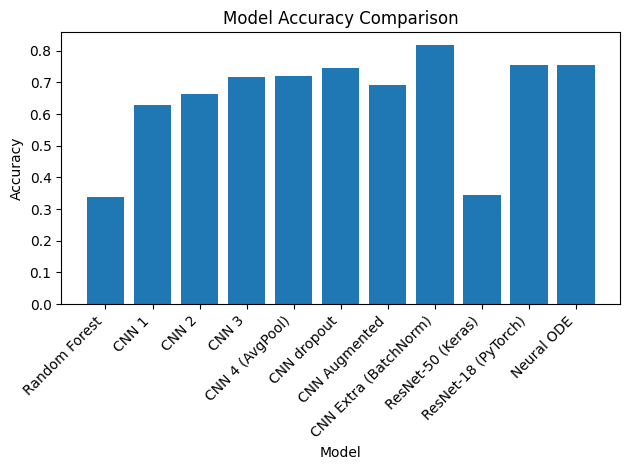

In [ ]:
df['Accuracy'] = df['Accuracy'].astype(float)

plt.figure()
plt.bar(df['Model'], df['Accuracy'])
plt.xticks(rotation=45, ha='right')
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

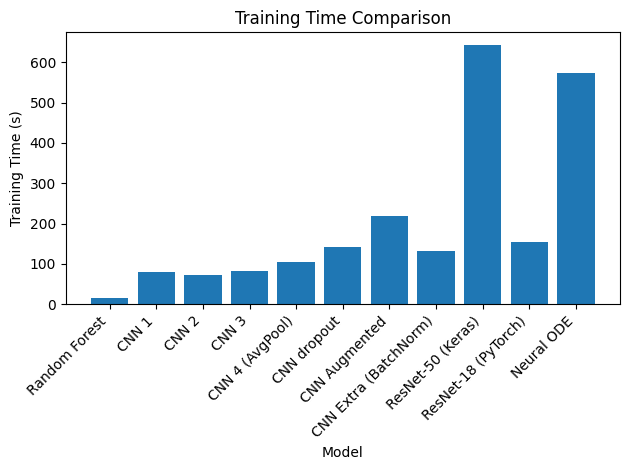

In [45]:
plt.figure()
plt.bar(df['Model'], df['Train Time (s)'])
plt.xticks(rotation=45, ha='right')
plt.xlabel("Model")
plt.ylabel("Training Time (s)")
plt.title("Training Time Comparison")
plt.tight_layout()
plt.show()

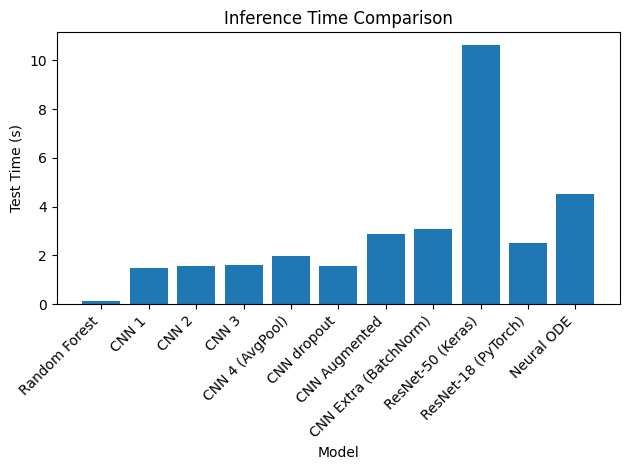

In [46]:
plt.figure()
plt.bar(df['Model'], df['Test Time (s)'])
plt.xticks(rotation=45, ha='right')
plt.xlabel("Model")
plt.ylabel("Test Time (s)")
plt.title("Inference Time Comparison")
plt.tight_layout()
plt.show()

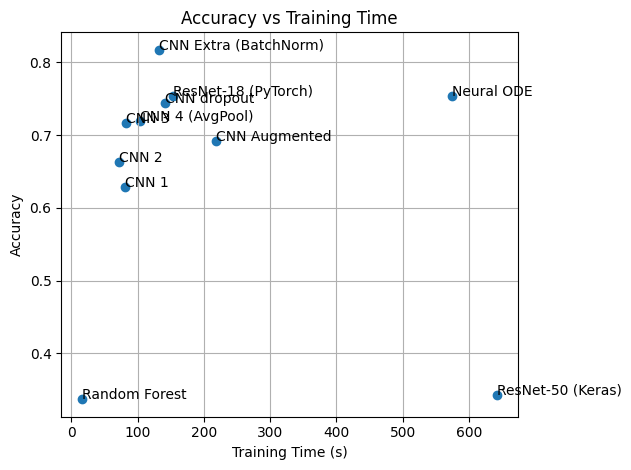

In [47]:
plt.figure()
plt.scatter(df['Train Time (s)'], df['Accuracy'])

for i, model in enumerate(df['Model']):
    plt.text(df['Train Time (s)'][i], df['Accuracy'][i], model)

plt.xlabel("Training Time (s)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Training Time")
plt.grid(True)
plt.tight_layout()
plt.show()

The results show a performance gap between the shallow and deep learning models. The Random Forest achieves a lower accuracy of 0.3370, compared to the other models. So this model is not sufficient for this image classification task (counting on features extraction). But, all CNN-based models significantly outperform it, with accuracy improving as architectural becomes more complex.

Among the CNN models, we added dropout and batch normalization that leads to improvements, with the CNN Extra (BatchNorm) model achieving the best overall accuracy of 0.8172. However, this improvement comes at the cost of increased training and inference time. Data augmentation also improves generalization but substantially increases training time.

The ResNet-18 model provides a strong balance between performance (0.7544 accuracy) and computational cost, whereas ResNet-50 performs poorly in this part, we assume due to insufficient training or suboptimal tuning despite its high computational cost. 

We are very interested in understanding Neural ODE, an improvement from ResNET, so we decided to try to implement it. The Neural ODE achieves competitive accuracy comparable to ResNet-18 but requires significantly longer training time.

Overall, the results highlight the trade-off between accuracy and computational efficiency, with more advanced architectures generally yielding better performance at the expense of increased training and testing time.